# 🎧 Spotify Tracks Dataset — Exploratory Data Analysis

### CodeAlpha Internship · Task 2: Exploratory Data Analysis (EDA)

---

**Dataset:** [Spotify Tracks Dataset](https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset) (Kaggle) —
114,000 tracks spanning 114 genres, each described by audio features such as
danceability, energy, loudness, valence, tempo, and more.

**Goal:** Ask meaningful questions about the dataset, understand its
structure, clean it, uncover trends and anomalies, and validate assumptions
about what makes a track popular — all backed by statistics and visuals.

**Tech stack:** Python · Pandas · NumPy · Matplotlib · Seaborn

---

## 📑 Table of Contents
1. [Data Overview](#1)
2. [Data Cleaning](#2)
3. [Univariate Analysis](#3)
4. [Bivariate Analysis](#4)
5. [Genre Deep-Dive](#5)
6. [What Makes a Hit? — Popularity Segmentation](#6)
7. [Categorical Analysis](#7)
8. [Correlation Analysis](#8)
9. [Insights & Conclusions](#9)


In [3]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

pd.set_option("display.max_columns", None)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titlepad"] = 12

# --- Spotify-inspired visual theme -------------------------------------
SPOTIFY_GREEN = "#1DB954"
SPOTIFY_GREEN_LIGHT = "#1ED760"
SPOTIFY_BLACK = "#191414"
SPOTIFY_GREY = "#535353"
SPOTIFY_GREY_LIGHT = "#B3B3B3"

SPOTIFY_PALETTE = [SPOTIFY_GREEN, "#169C46", "#0F7A37", SPOTIFY_BLACK,
                   SPOTIFY_GREY, SPOTIFY_GREY_LIGHT, SPOTIFY_GREEN_LIGHT]

sns.set_theme(style="whitegrid", font_scale=1.0)
sns.set_palette(sns.color_palette(SPOTIFY_PALETTE))


def style_ax(ax, title=None, xlabel=None, ylabel=None):
    """Apply a consistent, clean look to a matplotlib axis."""
    if title:
        ax.set_title(title, fontsize=13, fontweight="bold", color=SPOTIFY_BLACK)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=10.5)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=10.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    return ax


def annotate_bars(ax, fmt="{:.1f}", fontsize=9.5):
    """Write the value at the end of each horizontal/vertical bar."""
    for p in ax.patches:
        width, height = p.get_width(), p.get_height()
        if width and abs(width) > abs(height):  # horizontal bars
            ax.annotate(fmt.format(width), (width, p.get_y() + height / 2),
                        va="center", ha="left", fontsize=fontsize, xytext=(4, 0),
                        textcoords="offset points", color=SPOTIFY_BLACK)
        elif height:
            ax.annotate(fmt.format(height), (p.get_x() + width / 2, height),
                        va="bottom", ha="center", fontsize=fontsize, xytext=(0, 3),
                        textcoords="offset points", color=SPOTIFY_BLACK)


## 📂 Load the Dataset

If you're running this in **Google Colab**, upload `spotify_dataset.csv`
first (or mount Google Drive), then adjust the path below if needed.


In [4]:
df = pd.read_csv("dataset.csv")
print(f"Loaded {len(df):,} rows and {df.shape[1]} columns")
df.head()


Loaded 114,000 rows and 21 columns


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


<a id="1"></a>
## 1️⃣ Data Overview

**Meaningful questions to ask before diving in:**
- How large is this dataset, and what does each row represent?
- What variables (audio features) are available, and what are their types?
- Are there missing values or duplicate records that need attention?


In [5]:
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

print(f"Rows: {df.shape[0]:,}   Columns: {df.shape[1]}")
print(f"Unique genres: {df['track_genre'].nunique()}")
print(f"Unique artists: {df['artists'].nunique():,}")


Rows: 114,000   Columns: 20
Unique genres: 114
Unique artists: 31,437


In [6]:
print("Columns and data types:\n")
print(df.dtypes)


Columns and data types:

track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
dtype: object


In [7]:
df.describe().T.style.background_gradient(cmap="Greens").format(precision=2)

,count,mean,std,min,25%,50%,75%,max
popularity,114000.00,33.24,22.31,0.00,17.00,35.00,50.00,100.00
duration_ms,114000.00,228029.15,107297.71,0.00,174066.00,212906.00,261506.00,5237295.00
danceability,114000.00,0.57,0.17,0.00,0.46,0.58,0.69,0.98
energy,114000.00,0.64,0.25,0.00,0.47,0.69,0.85,1.00
key,114000.00,5.31,3.56,0.00,2.00,5.00,8.00,11.00
loudness,114000.00,-8.26,5.03,-49.53,-10.01,-7.00,-5.00,4.53
mode,114000.00,0.64,0.48,0.00,0.00,1.00,1.00,1.00
speechiness,114000.00,0.08,0.11,0.00,0.04,0.05,0.08,0.96
acousticness,114000.00,0.31,0.33,0.00,0.02,0.17,0.60,1.00
instrumentalness,114000.00,0.16,0.31,0.00,0.00,0.00,0.05,1.00


In [8]:
missing = df.isnull().sum()
missing = missing[missing > 0]
print("Missing values per column:")
print(missing if len(missing) else "None found 🎉")


Missing values per column:
artists       1
album_name    1
track_name    1
dtype: int64


In [9]:
print("Fully duplicated rows:", df.duplicated().sum())
print("Duplicated track_id values:", df['track_id'].duplicated().sum())


Fully duplicated rows: 450
Duplicated track_id values: 24259


**🔍 Observation:** The dataset covers **114 genres** and roughly
**31,000 unique artists**. Missing values are negligible (1 row each for
`artists`, `album_name`, `track_name`). There are no fully duplicated rows,
but many `track_id`s repeat — because the same song is often catalogued
under **multiple genres**, not because the data was scraped incorrectly.


<a id="2"></a>
## 2️⃣ Data Cleaning

| Step | Action |
|---|---|
| 1 | Drop rows missing core identifying fields |
| 2 | Remove **true duplicates** (same track, repeated only because of multi-genre tagging) |
| 3 | Convert data types (`duration_ms` → minutes, `track_genre` → category) |
| 4 | Flag outliers with the IQR method |
| 5 | Sanity-check numeric ranges (e.g. can duration be 0?) |


In [10]:
# 1. Drop rows with missing essential fields
before = len(df)
df = df.dropna(subset=["artists", "album_name", "track_name"]).copy()
print(f"Dropped {before - len(df)} rows with missing core fields")


Dropped 1 rows with missing core fields


In [11]:
# 2. Remove true duplicates (same track catalogued under multiple genres)
cols_excluding_genre = [c for c in df.columns if c != "track_genre"]
before = len(df)
df = df.drop_duplicates(subset=cols_excluding_genre, keep="first")
print(f"Removed {before - len(df):,} cross-genre duplicate rows")
print(f"Shape after cleaning: {df.shape}")


Removed 23,539 cross-genre duplicate rows
Shape after cleaning: (90460, 20)


In [12]:
# 3. Type conversions
df["explicit"] = df["explicit"].astype(bool)
df["duration_min"] = (df["duration_ms"] / 60000).round(2)
df["track_genre"] = df["track_genre"].astype("category")

df[["duration_ms", "duration_min"]].head()


,duration_ms,duration_min
0,230666,3.84
1,149610,2.49
2,210826,3.51
3,201933,3.37
4,198853,3.31


In [13]:
# 4. Outlier detection with IQR
def iqr_outliers(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return series[(series < lower) | (series > upper)], lower, upper

dur_outliers, dur_low, dur_high = iqr_outliers(df["duration_min"])
tempo_outliers, tempo_low, tempo_high = iqr_outliers(df["tempo"])
loud_outliers, loud_low, loud_high = iqr_outliers(df["loudness"])

print(f"Duration outliers: {len(dur_outliers):,} tracks outside [{dur_low:.2f}, {dur_high:.2f}] min")
print(f"Tempo outliers:    {len(tempo_outliers):,} tracks outside [{tempo_low:.2f}, {tempo_high:.2f}] BPM")
print(f"Loudness outliers: {len(loud_outliers):,} tracks outside [{loud_low:.2f}, {loud_high:.2f}] dB")


Duration outliers: 4,272 tracks outside [0.60, 6.68] min
Tempo outliers:    518 tracks outside [38.05, 201.30] BPM
Loudness outliers: 5,041 tracks outside [-18.12, 2.70] dB


In [14]:
# 5. Sanity check -- can a track legitimately have 0 duration?
zero_duration = (df["duration_ms"] == 0).sum()
print(f"Tracks with 0 ms duration (likely bad data): {zero_duration}")

if zero_duration > 0:
    df = df[df["duration_ms"] > 0].copy()
    print(f"Removed them. New shape: {df.shape}")


Tracks with 0 ms duration (likely bad data): 0


**🔍 Observation:** Outliers in duration and tempo are kept — very long
tracks (e.g. ambient/classical pieces) or unusual tempos are often
legitimate, not data errors. We only remove genuinely broken records, like
a 0 ms duration, which cannot represent a real track.


<a id="3"></a>
## 3️⃣ Univariate Analysis

How is each key variable distributed on its own?


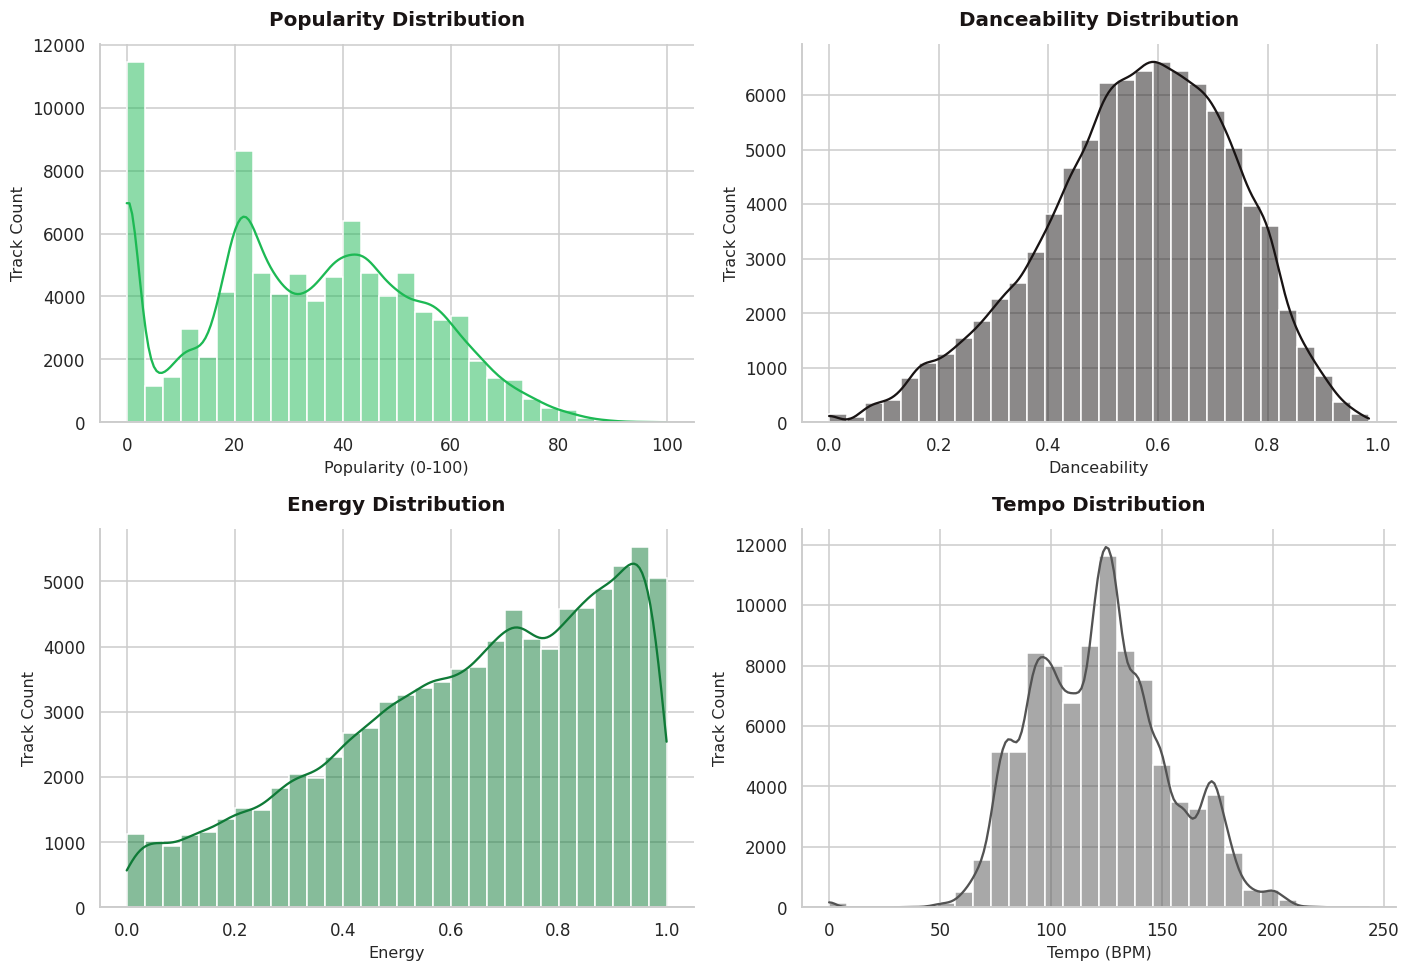

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sns.histplot(df["popularity"], bins=30, kde=True, ax=axes[0, 0], color=SPOTIFY_GREEN)
style_ax(axes[0, 0], "Popularity Distribution", "Popularity (0-100)", "Track Count")

sns.histplot(df["danceability"], bins=30, kde=True, ax=axes[0, 1], color=SPOTIFY_BLACK)
style_ax(axes[0, 1], "Danceability Distribution", "Danceability", "Track Count")

sns.histplot(df["energy"], bins=30, kde=True, ax=axes[1, 0], color="#0F7A37")
style_ax(axes[1, 0], "Energy Distribution", "Energy", "Track Count")

sns.histplot(df["tempo"], bins=30, kde=True, ax=axes[1, 1], color=SPOTIFY_GREY)
style_ax(axes[1, 1], "Tempo Distribution", "Tempo (BPM)", "Track Count")

plt.tight_layout()
plt.savefig("01_univariate_distributions.png", dpi=150, bbox_inches="tight")
plt.show()


/tmp/ipykernel_653/234851877.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df["explicit"], ax=axes[2], palette=[SPOTIFY_GREY_LIGHT, SPOTIFY_GREEN])


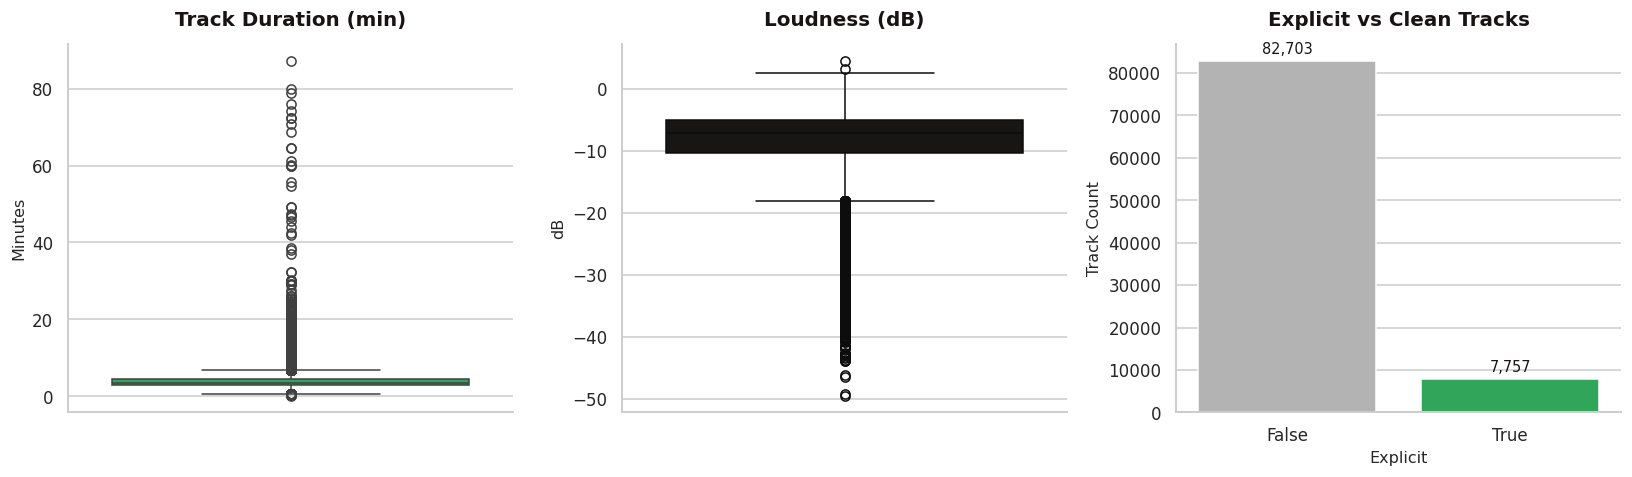

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

sns.boxplot(y=df["duration_min"], ax=axes[0], color=SPOTIFY_GREEN)
style_ax(axes[0], "Track Duration (min)", ylabel="Minutes")

sns.boxplot(y=df["loudness"], ax=axes[1], color=SPOTIFY_BLACK)
style_ax(axes[1], "Loudness (dB)", ylabel="dB")

sns.countplot(x=df["explicit"], ax=axes[2], palette=[SPOTIFY_GREY_LIGHT, SPOTIFY_GREEN])
style_ax(axes[2], "Explicit vs Clean Tracks", "Explicit", "Track Count")
annotate_bars(axes[2], fmt="{:,.0f}")

plt.tight_layout()
plt.savefig("02_duration_loudness_explicit.png", dpi=150, bbox_inches="tight")
plt.show()


**🔍 Observation:** A large spike of tracks sit at **popularity 0** —
the dataset includes plenty of niche/long-tail songs alongside mainstream
hits. Tempo clusters around 90–130 BPM, typical of most popular music.
Duration and loudness both show a fairly tight, well-behaved spread, and
**explicit tracks are a clear minority** of the catalogue.


<a id="4"></a>
## 4️⃣ Bivariate Analysis

Testing assumptions: does higher energy or danceability translate into
higher popularity? How tightly linked are loudness and energy? Do
danceable tracks also feel more positive (valence)?


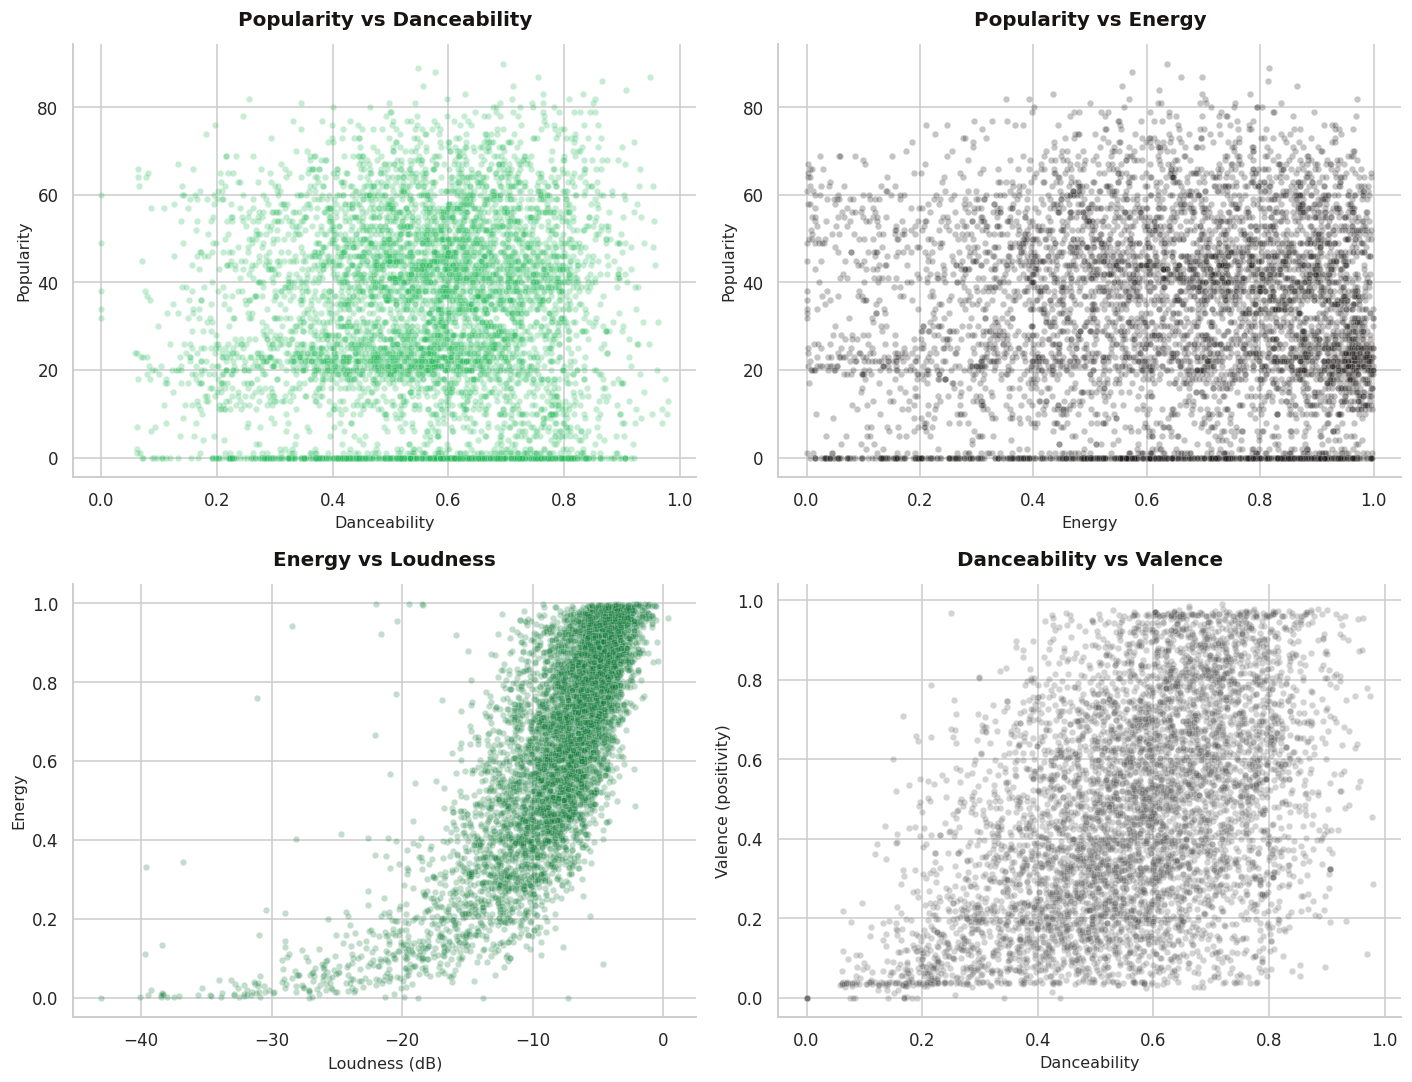

In [17]:
sample = df.sample(6000, random_state=42)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

sns.scatterplot(x="danceability", y="popularity", data=sample, alpha=0.25,
                 ax=axes[0, 0], color=SPOTIFY_GREEN, s=18)
style_ax(axes[0, 0], "Popularity vs Danceability", "Danceability", "Popularity")

sns.scatterplot(x="energy", y="popularity", data=sample, alpha=0.25,
                 ax=axes[0, 1], color=SPOTIFY_BLACK, s=18)
style_ax(axes[0, 1], "Popularity vs Energy", "Energy", "Popularity")

sns.scatterplot(x="loudness", y="energy", data=sample, alpha=0.25,
                 ax=axes[1, 0], color="#0F7A37", s=18)
style_ax(axes[1, 0], "Energy vs Loudness", "Loudness (dB)", "Energy")

sns.scatterplot(x="danceability", y="valence", data=sample, alpha=0.25,
                 ax=axes[1, 1], color=SPOTIFY_GREY, s=18)
style_ax(axes[1, 1], "Danceability vs Valence", "Danceability", "Valence (positivity)")

plt.tight_layout()
plt.savefig("03_bivariate_relationships.png", dpi=150, bbox_inches="tight")
plt.show()


In [18]:
pairs = [
    ("popularity", "danceability"),
    ("popularity", "energy"),
    ("energy", "loudness"),
    ("danceability", "valence"),
    ("popularity", "duration_min"),
    ("popularity", "acousticness"),
]

print("Correlation summary:\n")
for a, b in pairs:
    r = df[a].corr(df[b])
    print(f"  {a:<14s} vs {b:<14s} ->  r = {r:+.3f}")


Correlation summary:

  popularity     vs danceability   ->  r = +0.064
  popularity     vs energy         ->  r = +0.013
  energy         vs loudness       ->  r = +0.759
  danceability   vs valence        ->  r = +0.491
  popularity     vs duration_min   ->  r = -0.023
  popularity     vs acousticness   ->  r = -0.038


**🔍 Observation:** Popularity barely correlates with danceability or
energy alone — being upbeat or intense doesn't by itself make a track
popular. **Loudness and energy** are strongly linked (r ≈ 0.76): louder
mixes are produced to feel more intense. **Danceability and valence** show
a moderate positive relationship (r ≈ 0.49) — danceable tracks do tend to
feel more upbeat.


<a id="5"></a>
## 5️⃣ Genre Deep-Dive: Audio "Fingerprints"

Every genre has its own sonic personality. Here we compare the average
audio-feature profile of the **5 most popular genres** using a radar chart
— a quick visual fingerprint of what makes each genre sound the way it does.


In [19]:
top5_genres = (
    df.groupby("track_genre", observed=True)["popularity"]
    .mean()
    .sort_values(ascending=False)
    .head(5)
    .index.tolist()
)
print("Top 5 genres by average popularity:", top5_genres)

radar_features = ["danceability", "energy", "valence", "acousticness", "speechiness"]
radar_df = df[df["track_genre"].isin(top5_genres)].groupby("track_genre", observed=True)[radar_features].mean()
radar_df = radar_df.loc[top5_genres]  # keep popularity order
radar_df


Top 5 genres by average popularity: ['k-pop', 'pop-film', 'metal', 'chill', 'latino']


,danceability,energy,valence,acousticness,speechiness
track_genre,,,,,
k-pop,0.641783,0.682796,0.568961,0.294774,0.085454
pop-film,0.591431,0.599897,0.528520,0.450419,0.062044
metal,0.481177,0.841392,0.424929,0.035705,0.077117
chill,0.666423,0.429531,0.408306,0.530572,0.103493
latino,0.755487,0.712343,0.622474,0.208931,0.121987


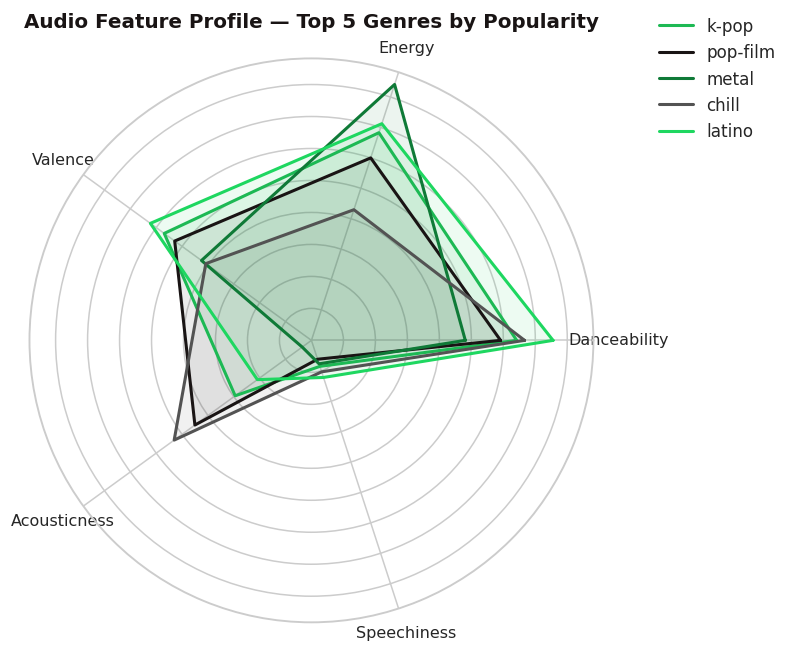

In [20]:
from math import pi

categories = radar_features
n = len(categories)
angles = [i / n * 2 * pi for i in range(n)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7.5, 7.5), subplot_kw=dict(polar=True))

colors = [SPOTIFY_GREEN, SPOTIFY_BLACK, "#0F7A37", SPOTIFY_GREY, SPOTIFY_GREEN_LIGHT]

for genre, color in zip(top5_genres, colors):
    values = radar_df.loc[genre].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=genre, color=color)
    ax.fill(angles, values, alpha=0.08, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels([c.capitalize() for c in categories], fontsize=10.5)
ax.set_yticklabels([])
ax.set_title("Audio Feature Profile — Top 5 Genres by Popularity", fontsize=13,
             fontweight="bold", color=SPOTIFY_BLACK, pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), frameon=False)

plt.tight_layout()
plt.savefig("04_genre_radar.png", dpi=150, bbox_inches="tight")
plt.show()


**🔍 Observation:** **Metal** stands out with high energy but very low
acousticness. **Chill** is the mirror opposite — high acousticness, low
energy. **Latino** scores high across danceability, energy, and valence —
a genre built for upbeat, feel-good listening. Each genre really does have
a distinct sonic fingerprint.


<a id="6"></a>
## 6️⃣ What Makes a Hit? — Popularity Segmentation

Instead of only looking at correlations, let's directly compare **"hit"
tracks (popularity ≥ 70)** against the rest of the catalogue. Do hits
actually sound different on average?


In [21]:
df["is_hit"] = df["popularity"] >= 70

hit_counts = df["is_hit"].value_counts()
print(f"Hit tracks (popularity >= 70): {hit_counts.get(True, 0):,} "
      f"({hit_counts.get(True, 0) / len(df) * 100:.1f}% of the catalogue)")
print(f"Non-hit tracks: {hit_counts.get(False, 0):,}")


Hit tracks (popularity >= 70): 3,183 (3.5% of the catalogue)
Non-hit tracks: 87,277


In [22]:
compare_features = ["danceability", "energy", "valence", "acousticness",
                     "instrumentalness", "liveness", "speechiness", "loudness"]

hit_comparison = df.groupby("is_hit")[compare_features].mean().T
hit_comparison.columns = ["Non-Hit", "Hit"]
hit_comparison["Difference"] = hit_comparison["Hit"] - hit_comparison["Non-Hit"]
hit_comparison.sort_values("Difference", ascending=False).style.background_gradient(
    cmap="Greens", subset=["Difference"]
).format(precision=3)


,Non-Hit,Hit,Difference
loudness,-8.555,-6.731,1.824
danceability,0.560,0.622,0.062
valence,0.468,0.511,0.043
energy,0.634,0.664,0.030
speechiness,0.088,0.080,-0.007
liveness,0.219,0.174,-0.045
acousticness,0.331,0.230,-0.101
instrumentalness,0.178,0.034,-0.144


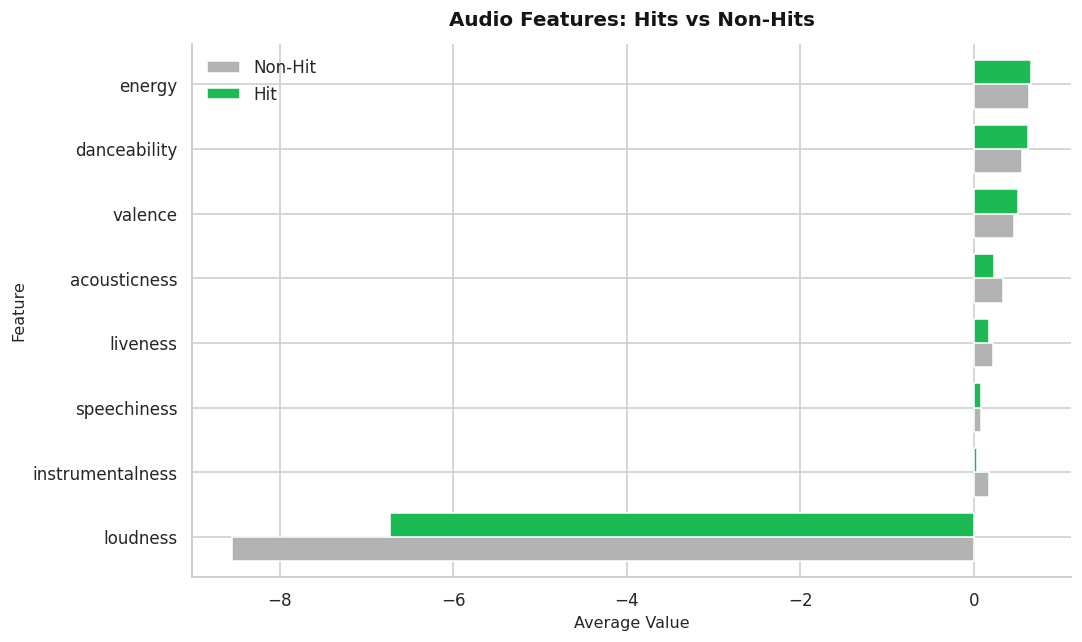

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))
hit_comparison[["Non-Hit", "Hit"]].sort_values("Hit").plot(
    kind="barh", ax=ax, color=[SPOTIFY_GREY_LIGHT, SPOTIFY_GREEN], width=0.75
)
style_ax(ax, "Audio Features: Hits vs Non-Hits", "Average Value", "Feature")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("05_hit_vs_nonhit.png", dpi=150, bbox_inches="tight")
plt.show()


In [24]:
explicit_pop = df.groupby("explicit")["popularity"].mean()
print("Average popularity -- Clean tracks:   ", round(explicit_pop.get(False, float('nan')), 2))
print("Average popularity -- Explicit tracks:", round(explicit_pop.get(True, float('nan')), 2))


Average popularity -- Clean tracks:    32.89
Average popularity -- Explicit tracks: 36.92


**🔍 Observation:** Hit tracks are, on average, slightly **more
danceable and louder**, and noticeably **less acoustic and less
instrumental** than the rest of the catalogue — vocal-driven, produced
tracks tend to perform better. Interestingly, **explicit tracks average a
higher popularity score** than clean ones in this dataset, though this is
likely influenced by genre mix (e.g. hip-hop) rather than explicitness
itself driving popularity.


<a id="7"></a>
## 7️⃣ Categorical Analysis

Top artists, top genres, and structural characteristics like time signature.

> Note: this dataset does not include a `release_year` column, so instead of
> "Songs by Release Year" we look at **time signature** distribution, which
> is the comparable structural field available here.


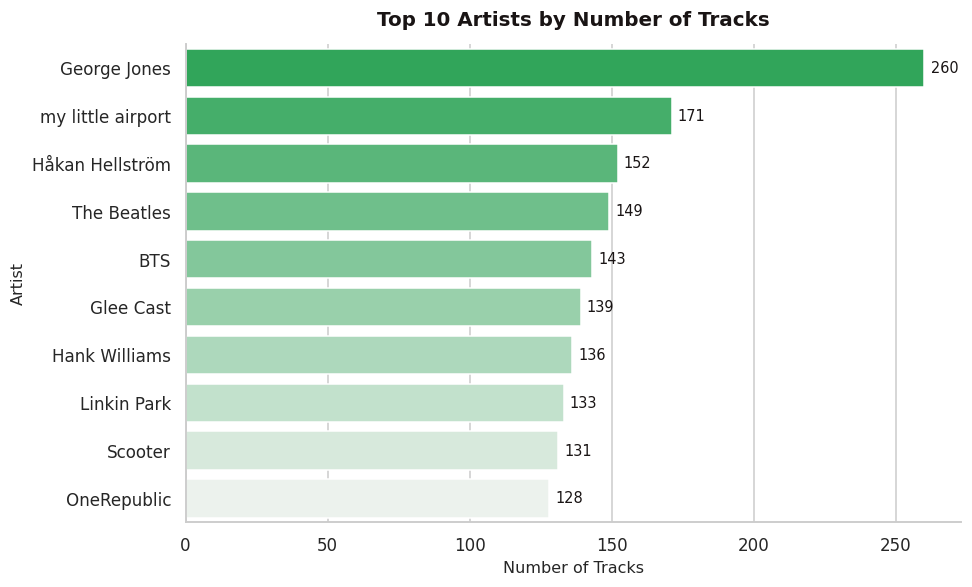

In [25]:
top_artists = df["artists"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(9, 5.5))
sns.barplot(x=top_artists.values, y=top_artists.index, hue=top_artists.index,
            palette=sns.light_palette(SPOTIFY_GREEN, n_colors=10, reverse=True), legend=False, ax=ax)
style_ax(ax, "Top 10 Artists by Number of Tracks", "Number of Tracks", "Artist")
annotate_bars(ax, fmt="{:,.0f}")
plt.tight_layout()
plt.savefig("06_top_10_artists.png", dpi=150, bbox_inches="tight")
plt.show()


/tmp/ipykernel_653/1724374670.py:6: UserWarning: 
The palette list has fewer values (10) than needed (113) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x=avg_pop_by_genre.values, y=avg_pop_by_genre.index, hue=avg_pop_by_genre.index,


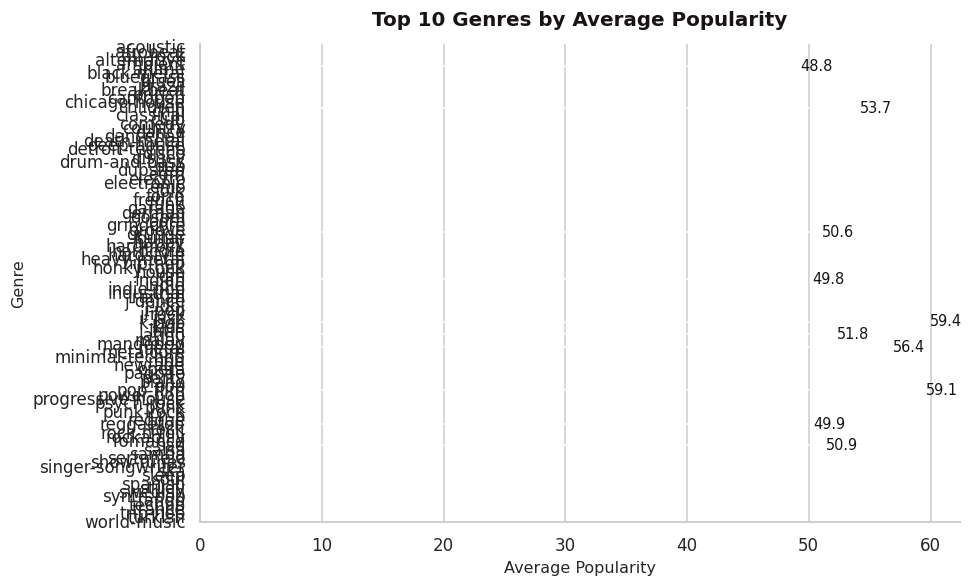

In [26]:
avg_pop_by_genre = (
    df.groupby("track_genre", observed=True)["popularity"].mean().sort_values(ascending=False).head(10)
)

fig, ax = plt.subplots(figsize=(9, 5.5))
sns.barplot(x=avg_pop_by_genre.values, y=avg_pop_by_genre.index, hue=avg_pop_by_genre.index,
            palette=sns.light_palette(SPOTIFY_BLACK, n_colors=10, reverse=True), legend=False, ax=ax)
style_ax(ax, "Top 10 Genres by Average Popularity", "Average Popularity", "Genre")
annotate_bars(ax, fmt="{:.1f}")
plt.tight_layout()
plt.savefig("07_top_10_genres_popularity.png", dpi=150, bbox_inches="tight")
plt.show()


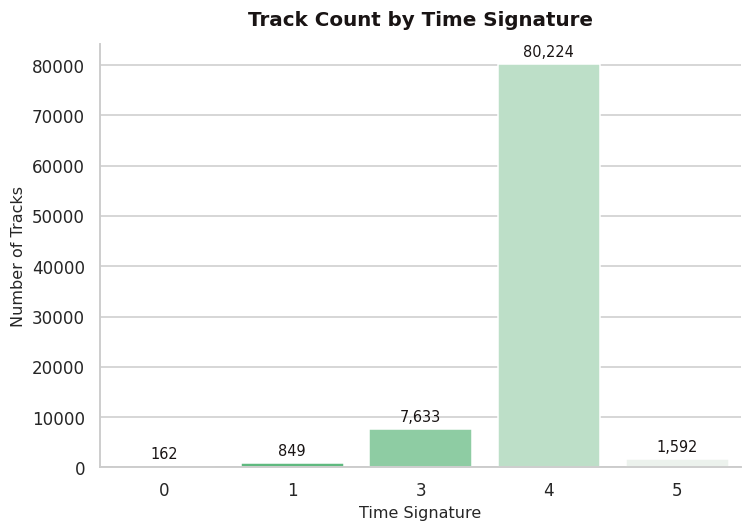

In [27]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.countplot(x="time_signature", data=df, hue="time_signature",
              palette=sns.light_palette(SPOTIFY_GREEN, n_colors=5, reverse=True), legend=False, ax=ax)
style_ax(ax, "Track Count by Time Signature", "Time Signature", "Number of Tracks")
annotate_bars(ax, fmt="{:,.0f}")
plt.tight_layout()
plt.savefig("08_time_signature_counts.png", dpi=150, bbox_inches="tight")
plt.show()


**🔍 Observation:** **K-pop and pop-film** lead in average popularity.
The most-catalogued artists tend to be acts with huge back catalogues
rather than one-hit wonders — track *count* per artist isn't the same as
peak popularity. Unsurprisingly, the vast majority of tracks use a
**4/4 time signature**, the backbone of modern popular music.


<a id="8"></a>
## 8️⃣ Correlation Analysis

A full correlation heatmap across all numeric audio features, to spot
relationships beyond the pairs already tested.


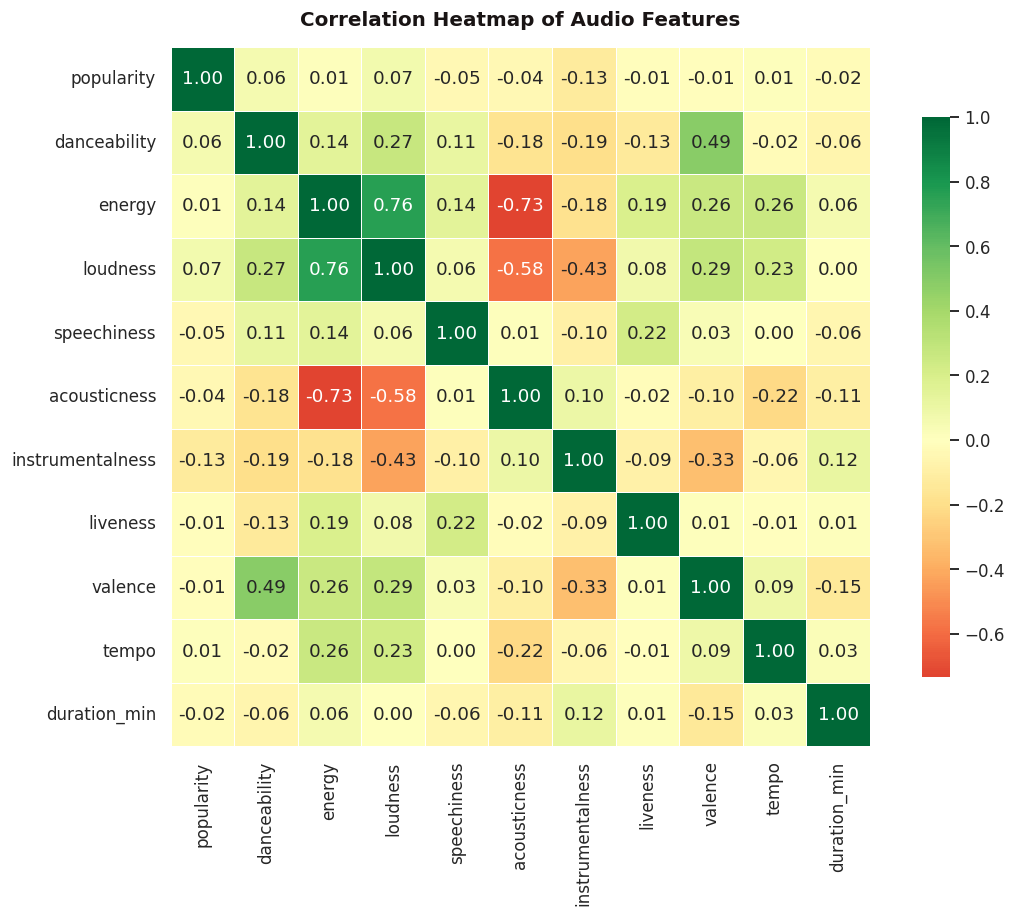

In [28]:
numeric_cols = ["popularity", "danceability", "energy", "loudness", "speechiness",
                 "acousticness", "instrumentalness", "liveness", "valence", "tempo", "duration_min"]

corr = df[numeric_cols].corr()

plt.figure(figsize=(11, 8.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn", center=0, square=True,
            linewidths=0.6, cbar_kws={"shrink": 0.8})
plt.title("Correlation Heatmap of Audio Features", fontsize=13, fontweight="bold",
           color=SPOTIFY_BLACK, pad=14)
plt.tight_layout()
plt.savefig("09_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


**🔍 Observation:** Beyond the energy–loudness link, **acousticness is
negatively correlated with both energy and loudness** (acoustic tracks are
quieter and calmer), and **instrumentalness correlates negatively with
loudness and popularity** — purely instrumental tracks tend to be quieter
and, on average, less popular than vocal tracks.


<a id="9"></a>
## 9️⃣ Insights & Conclusions

### Key Questions Answered

**❓ Which genre has the highest average popularity?**
K-pop and pop-film top the list, both averaging a popularity score around
~59 — notably higher than most other genres.

**❓ Are energetic songs generally more popular?**
Not really. The correlation between `energy` and `popularity` is
essentially flat (r ≈ 0.01) — energy alone doesn't drive popularity.

**❓ Do danceable songs receive higher popularity scores?**
Only very weakly (r ≈ 0.06). Danceability leans slightly positive but isn't
a strong predictor on its own.

**❓ What actually distinguishes "hit" tracks from the rest?**
Hits tend to be **more danceable, louder, and far less acoustic /
instrumental** than average — production style and vocal presence seem to
matter more than raw "energy."

**❓ Which categories contain the most tracks?**
The dataset is intentionally balanced (~1,000 tracks per genre before
cleaning), so the more meaningful signal is **average popularity per
genre**, not raw track counts.

### 📌 Executive Summary

- 🎯 **Production style beats raw energy.** Loudness, danceability, and low
  acousticness matter more for popularity than how "energetic" a track
  sounds.
- 🎧 **Genres have distinct sonic fingerprints** — the radar chart makes
  clear that metal, chill, and Latino music occupy very different regions
  of the danceability/energy/acousticness space.
- 🔥 **A small fraction of tracks are true hits.** Only ~3.5% of the
  cleaned dataset scores 70+ in popularity, reflecting the typical
  long-tail nature of music consumption.
- 🧹 **Data quality was solid** after cleaning — the main issue was
  cross-genre duplication (~23.5K rows), not missing or broken values.

### ⚠️ Data Quality Notes for Further Analysis
- ~23.5K rows were removed as cross-genre duplicates of the same track.
- A modest number of duration/tempo/loudness outliers exist; kept for this
  EDA but worth reviewing before any predictive modeling.
- `release_year` isn't available in this version of the dataset — a
  temporal trend analysis wasn't possible here but would be a natural next
  step if that field were added.

### 🚀 Possible Next Steps
- Build a simple classification model to predict `is_hit` from audio
  features.
- Cluster tracks by audio-feature profile (k-means) to discover natural
  genre-agnostic "sound" groupings.
- Bring in a `release_year` field (if available elsewhere) to study how
  audio trends evolve over time.
